# MLP на numpy: косинусное расписание и ранняя остановка

Ручная реализация из `ml_toolkit.trainer` на тех же данных digits и том же разбиении (seed=0), что и `04_digits_augmentation`.

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = "png"
plt.rcParams["figure.dpi"] = 72
from ml_toolkit.data import make_split
from ml_toolkit.features import make_preprocessor
from ml_toolkit.metrics import calc_metrics
from ml_toolkit.trainer import NumpyMLP, Trainer

In [2]:
split = make_split("digits", seed=0)
pre = make_preprocessor().fit(split.X_train)
X_tr, X_va, X_te = (pre.transform(x) for x in (split.X_train, split.X_val, split.X_test))
print(X_tr.shape, X_va.shape, X_te.shape)

(1077, 64) (360, 64) (360, 64)


## Обучение

lr = 0.005, до 80 эпох, батч 64, косинусное расписание с прогревом, SGD с моментом 0.9, weight decay 1e-3, ранняя остановка с patience = 10 по accuracy на валидации.

In [3]:
model = NumpyMLP(n_in=64, n_hidden=128, n_out=10, seed=0)
trainer = Trainer(model, lr=0.005, epochs=80, batch_size=64, schedule="cosine", momentum=0.9,
                  weight_decay=1e-3, patience=10, seed=0, verbose=True)
history = trainer.fit(X_tr, split.y_train, X_va, split.y_val)
print(f"stopped at epoch {trainer.stopped_epoch}, best epoch {history.best_epoch()}, "
      f"best val accuracy {max(history.val_accuracy):.4f}")

epoch   0  lr=0.0017  train_loss=2.9668  val_acc=0.1278
epoch  10  lr=0.0049  train_loss=0.2075  val_acc=0.9278
epoch  20  lr=0.0044  train_loss=0.1139  val_acc=0.9528
epoch  30  lr=0.0036  train_loss=0.0808  val_acc=0.9639
epoch  37  lr=0.0030  train_loss=0.0690  val_acc=0.9639
stopped at epoch 37, best epoch 27, best val accuracy 0.9639


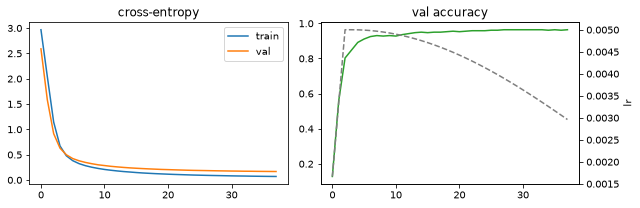

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.plot(history.train_loss, label="train")
ax1.plot(history.val_loss, label="val")
ax1.set_title("cross-entropy")
ax1.legend()
ax2.plot(history.val_accuracy, color="tab:green")
ax2.set_title("val accuracy")
ax3 = ax2.twinx()
ax3.plot(history.lr, color="tab:gray", ls="--")
ax3.set_ylabel("lr")
plt.tight_layout()
plt.show()

## Сравнение расписаний learning rate

Одинаковые гиперпараметры, до 40 эпох.

In [5]:
rows = []
for schedule in ["constant", "step", "cosine"]:
    m = NumpyMLP(64, 128, 10, seed=0)
    t = Trainer(m, lr=0.005, epochs=40, batch_size=64, weight_decay=1e-3, schedule=schedule, patience=10, seed=0)
    h = t.fit(X_tr, split.y_train, X_va, split.y_val)
    rows.append({"schedule": schedule, "best_val_acc": max(h.val_accuracy), "best_epoch": h.best_epoch(),
                 "stopped_epoch": t.stopped_epoch})
schedule_table = pd.DataFrame(rows).round(4)
schedule_table

,schedule,best_val_acc,best_epoch,stopped_epoch
0,constant,0.9639,25,35
1,step,0.9500,18,28
2,cosine,0.9583,24,34


## Тест

In [6]:
test_metrics = calc_metrics(split.y_test, model.predict(X_te), model.predict_proba(X_te))
print("TEST:", {k: round(v, 4) for k, v in test_metrics.items()})

TEST: {'accuracy': 0.9528, 'f1': 0.9527, 'roc_auc': 0.9947}


Ручной MLP сопоставим с `MLPClassifier` из `04_digits_augmentation`; лучшее расписание — в таблице выше.